# Data Analysis

We have already performed some basic data preprocessing in the previous notebook. Now, we will dive deeper into the data to extract insights and understand the electoral and demographic landscape in Spain for the 2019 and 2023 general elections.

In [218]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


from src.config import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [219]:
gdf = gpd.read_file(BASE_DIR / 'data' / 'processed' / 'combined_data.gpkg')
pd.options.display.float_format = '{:,.2f}'.format

## Dataset Overview
To get an overview of the dataset, we will check the shape of the GeoDataFrame, its information, and preview the first few rows. We also check for duplicates and missing values in the dataset to ensure data quality before proceeding with the analysis.

In [220]:
print('Shape of the GeoDataFrame:', gdf.shape)
gdf.info()
# Preview the data
display(gdf.head())

Shape of the GeoDataFrame: (8131, 41)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8131 entries, 0 to 8130
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   objectid              8131 non-null   int64   
 1   natcode               8131 non-null   str     
 2   nombre                8131 non-null   str     
 3   cod_nut1              8131 non-null   str     
 4   cod_nut2              8131 non-null   str     
 5   cod_nut3              8131 non-null   str     
 6   codmun_ine            8131 non-null   str     
 7   ccaa                  8131 non-null   str     
 8   cod_ccaa              8131 non-null   str     
 9   cod_pro               8131 non-null   str     
 10  provincia             8131 non-null   str     
 11  pob_npmun             8131 non-null   float64 
 12  pob_23                8131 non-null   int64   
 13  dens_pob              8131 non-null   float64 
 14  edad_media

,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,Votos válidos_2019,PSOE_2019,VOX_2019,PP_2019,SUMAR_2019,PP_diff_2023_2019,PSOE_diff_2023_2019,VOX_diff_2023_2019,SUMAR_diff_2023_2019,geometry
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,1372,20.70,3.94,8.31,18.15,2.15,6.60,0.89,-5.69,"MULTIPOLYGON (((-2.52642 42.83195, -2.52663 42..."
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,5786,16.07,2.66,5.84,14.97,1.04,6.92,-0.31,-4.75,"MULTIPOLYGON (((-3.01619 43.04059, -3.01575 43..."
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,837,3.11,0.60,0.36,9.32,-0.08,4.42,0.09,-0.02,"MULTIPOLYGON (((-2.66113 43.06576, -2.66102 43..."
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,945,11.43,3.49,8.89,15.56,1.49,8.33,-0.17,-4.47,"MULTIPOLYGON (((-3.14189 43.16115, -3.14159 43..."
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,122,16.39,14.75,17.21,22.95,5.92,4.50,-3.56,-8.77,"MULTIPOLYGON (((-2.8803 42.69937, -2.87852 42...."


In [221]:
# Check for exact duplicate rows
print(f"Duplicates: {gdf.duplicated().sum()}")

# Check for missing values
print(gdf.isnull().sum())

Duplicates: 0
objectid                0
natcode                 0
nombre                  0
cod_nut1                0
cod_nut2                0
cod_nut3                0
codmun_ine              0
ccaa                    0
cod_ccaa                0
cod_pro                 0
provincia               0
pob_npmun               0
pob_23                  0
dens_pob                0
edad_media              0
afi_1000                0
paro_1000               0
porc_pob65              0
pob_esup16              0
porc_pob_e              0
rat_mascul              0
rta_nt_med              0
pob_14                  0
pob_14_23               0
centroid_x              0
centroid_y              0
Votos válidos_2023      0
PSOE_2023               0
VOX_2023                0
SUMAR_2023              0
PP_2023                 0
Votos válidos_2019      0
PSOE_2019               0
VOX_2019                0
PP_2019                 0
SUMAR_2019              0
PP_diff_2023_2019       0
PSOE_diff_2023_2019     

Fortunately, our dataset is clean and does not contain any duplicates or missing values, which allows us to proceed with the analysis without needing to perform additional data cleaning steps.

## Univariate Analysis
In this section, we will perform univariate analysis on the electoral and demographic variables in our dataset.

In [222]:
# Dataset Overview
display(gdf.describe().T)

,count,mean,std,min,25%,50%,75%,max
objectid,"8,131.00","4,066.00","2,347.36",1.00,"2,033.50","4,066.00","6,098.50","8,131.00"
pob_npmun,"8,131.00",42.46,16.66,0.00,30.66,42.62,54.20,94.44
pob_23,"8,131.00","5,906.10","48,325.52",3.00,154.00,530.00,"2,435.50","3,332,035.00"
dens_pob,"8,131.00",181.96,931.00,0.23,4.65,13.44,56.63,"27,807.94"
edad_media,"8,131.00",50.51,6.63,34.66,45.12,49.80,55.41,75.12
afi_1000,"8,131.00",443.71,343.99,0.00,279.29,381.35,507.09,"7,293.24"
paro_1000,"8,131.00",69.12,42.94,0.00,40.28,64.73,92.08,"1,000.00"
porc_pob65,"8,131.00",29.41,10.94,5.27,20.87,27.96,36.67,80.00
pob_esup16,"8,131.00",22.83,10.97,0.00,16.28,22.07,29.34,63.41
porc_pob_e,"8,131.00",7.24,7.62,0.00,2.11,4.96,10.09,88.61


In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def plot_distribution(series, title='Distribution Plot', xlabel=None, source_text=None, color=None, 
                      scale='linear', limits=None, kde=True, ax=None, show_stats=True):
    """
    Displays summary statistics and plots a histogram with mean, median, and IQR.
    
    Parameters:
    - series: The pandas Series to plot.
    - title: String for the chart title.
    - xlabel: String for the x-axis label.
    - source_text: String for the source citation to display at the bottom right.
    - color: String for the histogram color.
    - scale: 'linear', 'log', or 'symlog'.
    - limits: Tuple for x-axis limits (e.g., (0, 100000)). None by default.
    - kde: Boolean to show or hide the Kernel Density Estimate curve.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    - show_stats: Boolean to show or hide the printed summary statistics.
    """
    
    sns.set_theme(style="white")

    # 1. Optionally display formatted summary statistics
    if show_stats:
        print(f"--- Summary Statistics: {title} ---")
        display(series.describe().to_frame().T)
        
    # 2. Create an axis if none is provided (allows single-plot usage)
    if ax is None:
        fig, ax = plt.subplots()
    
    # 3. Determine log scale
    is_log = True if scale == 'log' else False
    
    # 4. Use histplot (Axes-level) instead of displot (Figure-level)
    sns.histplot(series, kde=kde, log_scale=is_log, color=color, ax=ax)
    
    # 5. Handle 'symlog'
    if scale == 'symlog':
        ax.set_xscale('symlog')
        
    # 6. Calculate statistics
    clean_data = series.dropna()
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    q1 = clean_data.quantile(0.25)
    q3 = clean_data.quantile(0.75)
    
    # 7. Add lines and spans using the specific `ax` object
    ax.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:,.2f}')
    ax.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:,.2f}')
    ax.axvspan(q1, q3, color='grey', alpha=0.3, label=f'IQR: {q1:,.2f} - {q3:,.2f}')
    
    # 8. Apply x-axis limits
    if limits:
        ax.set_xlim(limits)
        
    # 9. Apply Labels and Title
    if xlabel:
        ax.set_xlabel(xlabel)
    else:
        # Fallback to the series name if no explicit xlabel is provided
        ax.set_xlabel(series.name if series.name else "Value")
        
    ax.set_title(title)

    if source_text:
        # transform=ax.transAxes forces the coordinates to be 0-1 relative to the Axes
        ax.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom of the axis box
            source_text, 
            transform=ax.transAxes, 
            ha='right',              
            va='bottom',             
            fontsize=9, 
            color='#666666',         
            style='italic'           
        )

    sns.despine()
    
    ax.legend()
    
    # Return the ax object instead of calling plt.show() 
    # This gives you further control over the plot outside the function
    return ax

def plot_scatter(data, x, y, title='Scatter Plot', xlabel=None, ylabel=None, 
                 source_text=None, color='blue', alpha=0.2, trendline=True, 
                 xscale='linear', yscale='linear', 
                 xlim=None, ylim=None, show_corr=True, ax=None):
    """
    Plots a scatterplot comparing two variables, with optional scaling, limits, 
    trendlines, and correlation coefficient.
    
    Parameters:
    - data: The pandas DataFrame containing the data.
    - x: String, name of the column for the x-axis.
    - y: String, name of the column for the y-axis.
    - title: String for the chart title.
    - xlabel: String for the x-axis label. Defaults to column name.
    - ylabel: String for the y-axis label. Defaults to column name.
    - source_text: String for the source citation to display at the bottom right.
    - color: String for the point color.
    - alpha: Float (0 to 1) for point transparency.
    - trendline: Boolean to include a linear regression trendline.
    - xscale: 'linear', 'log', or 'symlog' for the x-axis.
    - yscale: 'linear', 'log', or 'symlog' for the y-axis.
    - xlim: Tuple for x-axis limits (e.g., (0, 1000)). None by default.
    - ylim: Tuple for y-axis limits (e.g., (-10, 50)). None by default.
    - show_corr: Boolean to compute and display the Pearson correlation coefficient.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    """
    
    sns.set_theme(style="white")

    # 1. Create an axis if none is provided
    if ax is None:
        fig, ax = plt.subplots()
        
    # 2. Draw the plot (with or without a trendline)
    if trendline:
        sns.regplot(data=data, x=x, y=y, color=color, 
                    scatter_kws={'alpha': alpha}, ax=ax,
                    logx=(xscale == 'log'))
    else:
        sns.scatterplot(data=data, x=x, y=y, color=color, alpha=alpha, ax=ax)
        
    # 3. Apply axis scaling
    if xscale in ['log', 'symlog']:
        ax.set_xscale(xscale)
    if yscale in ['log', 'symlog']:
        ax.set_yscale(yscale)
        
    # 4. Apply limits if provided
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
        
    # 5. Compute and display correlation if requested
    if show_corr:
        # Calculate Pearson correlation (pandas handles NaNs automatically)
        if xscale == 'log' and yscale == 'log':
            corr_val = np.log(data[x]).corr(np.log(data[y]))
        elif xscale == 'log':
            corr_val = np.log(data[x]).corr(data[y])
        elif yscale == 'log':
            corr_val = data[x].corr(np.log(data[y]))
        else:
            corr_val = data[x].corr(data[y])
        
        # Create a text box for the correlation
        textstr = f'Corr (r): {corr_val:.2f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        
        # Place text in the top-left corner using relative axes coordinates (0 to 1)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
    # 6. Apply Labels and Title
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    ax.set_title(title)

    if source_text:
        # transform=ax.transAxes forces the coordinates to be 0-1 relative to the Axes
        ax.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom of the axis box
            source_text, 
            transform=ax.transAxes, 
            ha='right',              
            va='bottom',             
            fontsize=9, 
            color='#666666',         
            style='italic'           
        )

    sns.despine()

    return ax

import matplotlib.pyplot as plt

def plot_spanish_map(
    gdf, 
    variable, 
    bins,
    cmap='viridis', 
    title=None,
    legend=True,
    legend_title='Leyend',
    source_text= None, 
    ax=None,
):
    """
    Plots a map of Spain with correctly styled insets for Canarias, Ceuta, and Melilla.
    
    Parameters:
    - gdf: The Spanish GeoDataFrame.
    - variable: String, the column name to plot.
    - bins: List of numbers for the legend breaks.
    - cmap: String, the colormap to use (default 'viridis').
    - title: String, the main title of the map.
    - legend: Boolean, whether to show the legend.
    - legend_title: String, the title appearing above the legend.
    - source_text: String, text to display as the source citation at the bottom right.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    """
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    else:
        fig = ax.figure

    # 1. Split the data
    gdf_main = gdf[~gdf[V_CCAA].isin([C_CCAA_CANARIAS, C_CCAA_CEUTA, C_CCAA_MELILLA])]
    gdf_canarias = gdf[gdf[V_CCAA] == C_CCAA_CANARIAS]
    gdf_ceuta = gdf[gdf[V_CCAA] == C_CCAA_CEUTA]
    gdf_melilla = gdf[gdf[V_CCAA] == C_CCAA_MELILLA]

    # 2. Plot the main map
    gdf_main.plot(
        column=variable,
        scheme='UserDefined',
        classification_kwds={'bins': bins}, 
        cmap=cmap,
        legend=legend,
        missing_kwds={"color": "lightgrey", "label": "No Data"}, 
        linewidth=0,
        ax=ax,
        legend_kwds={
            'loc': 'lower right',                 
            'title': legend_title, 
            'fmt': "{:,.0f}"                      
        }
    )

    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

    # Expand borders to make room for insets
    minx, miny, maxx, maxy = gdf_main.total_bounds
    width, height = maxx - minx, maxy - miny
    ax.set_xlim(minx - (width * 0.35), maxx)
    ax.set_axis_off()

    # 3. Create Inset Axes [left, bottom, width, height]
    ax_canarias = fig.add_axes([0.15, 0.15, 0.25, 0.2]) 
    ax_ceuta = fig.add_axes([0.25, 0.4, 0.05, 0.05])    
    ax_melilla = fig.add_axes([0.25, 0.5, 0.05, 0.05])   

    # 4. Plot the Insets
    insets = [
        (gdf_canarias, ax_canarias, "Canarias", 12),
        (gdf_ceuta, ax_ceuta, "Ceuta", 10),
        (gdf_melilla, ax_melilla, "Melilla", 10)
    ]

    for data, inset_ax, label, f_size in insets:
        # Only plot if the data exists (prevents errors if a territory is missing from the gdf)
        if not data.empty:
            data.plot(
                column=variable,
                scheme='UserDefined',
                classification_kwds={'bins': bins},
                cmap=cmap,
                legend=False,
                missing_kwds={"color": "lightgrey"},
                linewidth=0,
                ax=inset_ax
            )
            
            # Zoom tightly on the inset landmass
            i_minx, i_miny, i_maxx, i_maxy = data.total_bounds
            x_buff = (i_maxx - i_minx) * 0.1
            y_buff = (i_maxy - i_miny) * 0.1
            inset_ax.set_xlim(i_minx - x_buff, i_maxx + x_buff)
            inset_ax.set_ylim(i_miny - y_buff, i_maxy + y_buff)
        
        # Style the box
        inset_ax.set_facecolor('white') 
        for spine in inset_ax.spines.values():
            spine.set_visible(True)          
            spine.set_edgecolor('#cccccc')    
            spine.set_linewidth(0.8)         
        
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        inset_ax.set_title(label, fontsize=f_size, pad=5, color='#333333')



    if source_text:
        # fig.text uses coordinates from 0 to 1 relative to the whole figure size
        fig.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom
            source_text, 
            ha='right',              # Horizontal alignment: right
            va='bottom',             # Vertical alignment: bottom
            fontsize=9, 
            color='#666666',         # A subtle grey color
            style='italic'           # Standard styling for citations
        )
    
    # Return figure and axes in case you want to save the figure later
    return fig, ax

### Population in 2023
The population variable gives us insight into the size of the municipalities. We can analyze its distribution to understand how population sizes vary across municipalities in Spain.

--- Summary Statistics: Distribution of Population in 2023 ---


,count,mean,std,min,25%,50%,75%,max
pob_23,"8,131.00","5,906.10","48,325.52",3.00,154.00,530.00,"2,435.50","3,332,035.00"


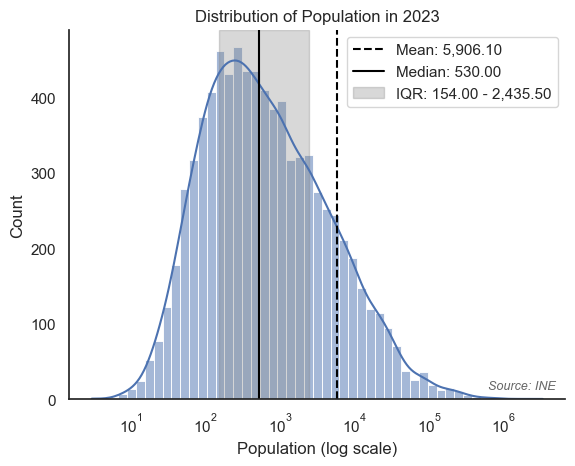

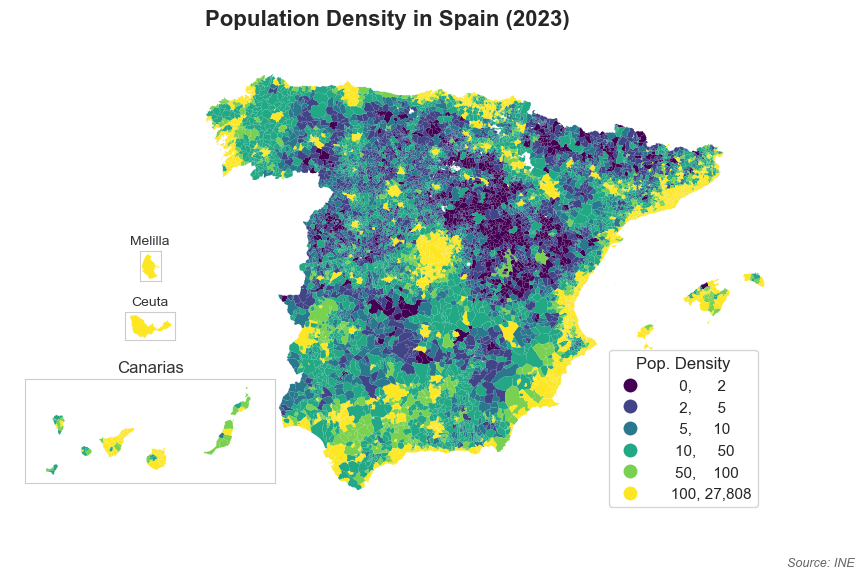

In [224]:
plot, ax = plt.subplots(figsize=(6.4, 4.8))
plot_distribution(
        gdf[V_Population_2023], 
        title='Distribution of Population in 2023',
        source_text='Source: INE',
        xlabel='Population (log scale)', 
        scale='log',
        ax=ax
)
plot.savefig('02_images/02_distribution_population.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_Population_density, 
    bins=[2, 5, 10, 50, 100], 
    cmap='viridis', 
    title='Population Density in Spain (2023)', 
    legend_title='Pop. Density',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_population.png', bbox_inches='tight', dpi=300)


As we can see from the histogram, the population distribution is right-skewed, indicating that there are many municipalities with small populations and a few with larger populations. The mean population is around 5,900 while the median is around 500 and even the third quartile is around 2,500, still much lower than the mean, which confirms the extreme skewness of the distribution. Therefore, 75% of the municipalities have a population of less than 2,500, while we can find a few large cities with populations exceeding 100,000, and even Madrid and Barcelona with a population of 3 million and 1.6 million respectively. Consequently, the huge number of small municipalities in Spain may distort the analysis when compared with the agregate data. Also, the presence of large cities like Madrid and Barcelona may also distort the analysis, as they are outliers in terms of population size.

### Population change between 2014 and 2023
The population change variable allows us to analyze how the population has changed between 2019 and 2023. We can analyze its distribution to understand the trends in population growth or decline across municipalities in Spain.

--- Summary Statistics: Distribution of Population Change between 2014 and 2023 ---


,count,mean,std,min,25%,50%,75%,max
pob_14_23,"8,131.00",-3.68,14.26,-67.75,-12.63,-4.19,4.22,150.00


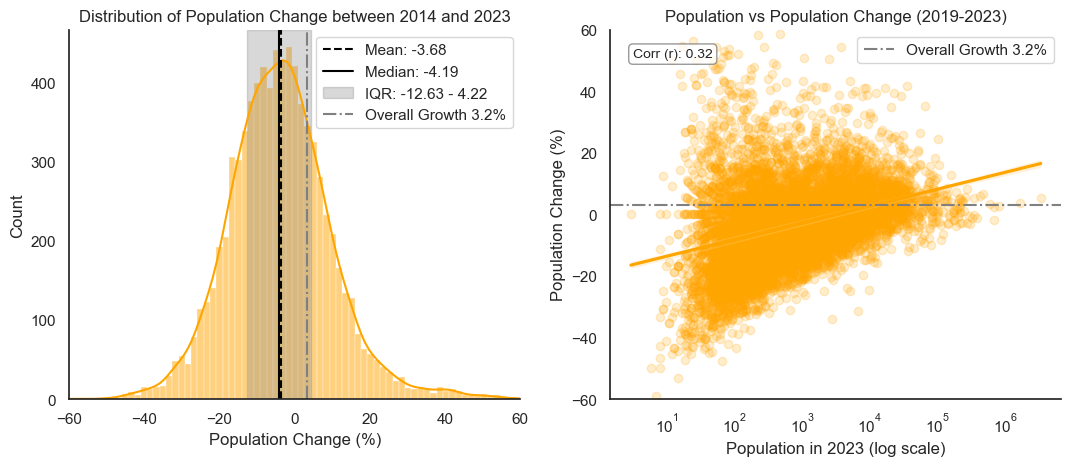

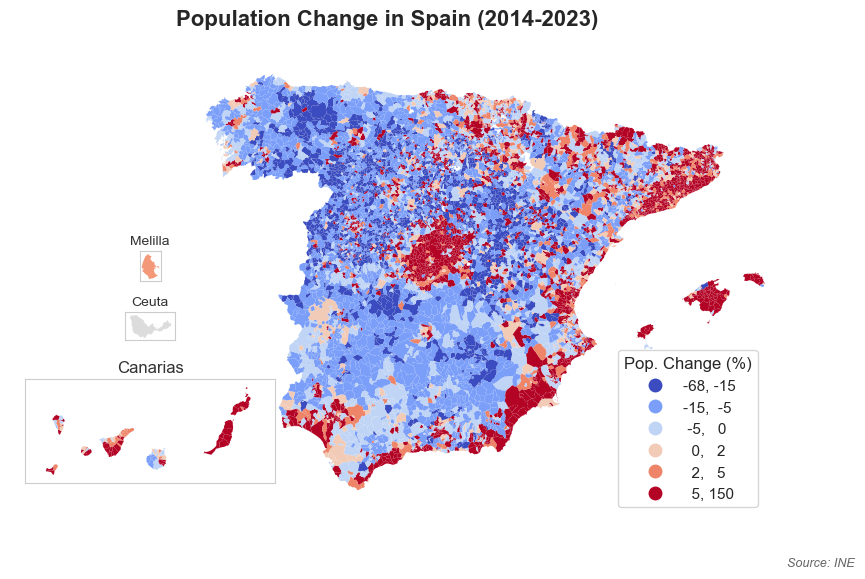

In [225]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_Population_change],
        title='Distribution of Population Change between 2014 and 2023',
        xlabel='Population Change (%)',
        color='orange',
        limits=(-60, 60),
        ax=axes[0]
)
axes[0].axvline(3.2, color='grey', linestyle='-.', label=f'Overall Growth {3.2:,.1f}%')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Population_change,
        title='Population vs Population Change (2019-2023)',
        xlabel='Population in 2023 (log scale)',
        ylabel='Population Change (%)',
        color='orange',
        xscale='log',
        ylim=(-60, 60),
        ax=axes[1]
)
axes[1].axhline(3.2, color='grey', linestyle='-.', label=f'Overall Growth {3.2:,.1f}%')
axes[1].legend()
plot.savefig('02_images/02_distribution_population_change.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_Population_change, 
    bins=[-15, -5, 0, 2, 5], 
    cmap='coolwarm', 
    title='Population Change in Spain (2014-2023)', 
    legend_title='Pop. Change (%)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_population_change.png', bbox_inches='tight', dpi=300)

From 2014 to 2023, the total population in Spain increased from 46.5 million to 48 million, which represents a growth of around 3.2%. However, this growth is not uniform across all municipalities. Municipalities with smaller populations tend to be rural and have older populations, making them less attractive for inmigration, which leads to population decline due to outmigration and low birth rates. As the distribution of the population is dramatically skewed, as discussed before, the average municipality experienced a population decline of around 3.68%.

### Mean age
The mean age variable is an important demographic when analyzing electoral behavior, as it can influence voting patterns. We can analyze its distribution to understand the age demographics of the municipalities in Spain.

--- Summary Statistics: Distribution of Mean Age ---


,count,mean,std,min,25%,50%,75%,max
edad_media,"8,131.00",50.51,6.63,34.66,45.12,49.80,55.41,75.12


--- Summary Statistics: Distribution of Population over 65 ---


,count,mean,std,min,25%,50%,75%,max
porc_pob65,"8,131.00",29.41,10.94,5.27,20.87,27.96,36.67,80.00


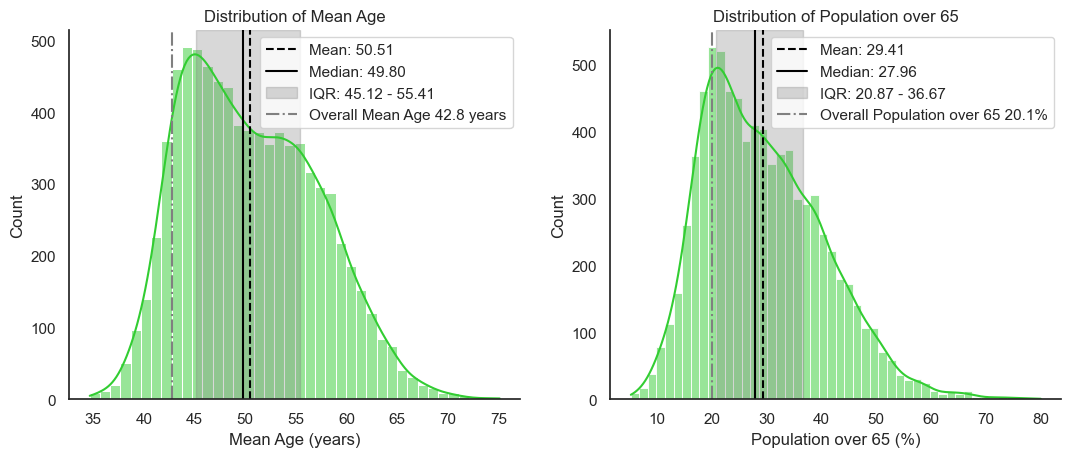

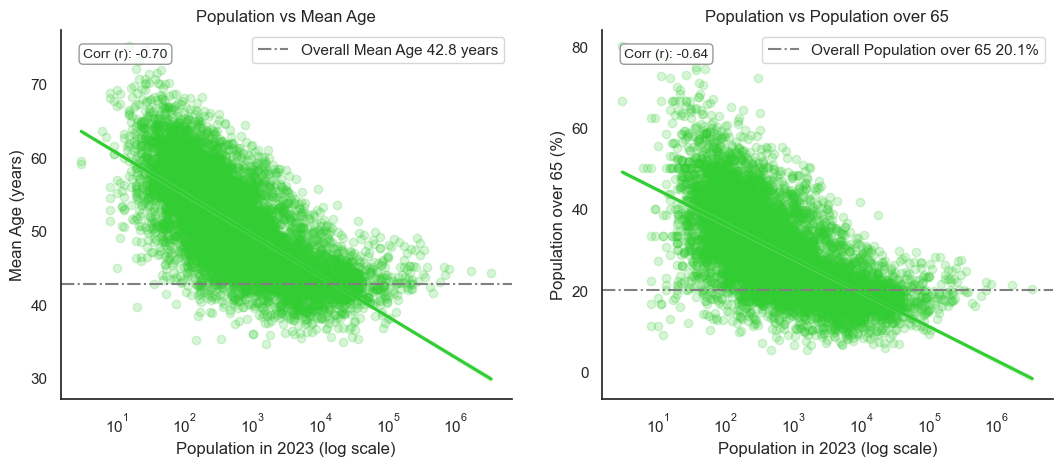

In [230]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_Mean_age],
        title='Distribution of Mean Age',
        xlabel='Mean Age (years)',
        color='limegreen',
        scale='linear',
        ax=axes[0]
)
axes[0].axvline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
axes[0].legend()
plot_distribution(
        gdf[V_Population_over_65],
        title='Distribution of Population over 65',
        xlabel='Population over 65 (%)',
        color='limegreen',
        scale='linear',
        ax=axes[1]
)
axes[1].axvline(20.15, color='grey', linestyle='-.', label=f'Overall Population over 65 {20.15:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_distribution_age.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Mean_age,
        title='Population vs Mean Age',
        xlabel='Population in 2023 (log scale)',
        ylabel='Mean Age (years)',
        xscale='log',
        color='limegreen',
        ax=axes[0]
)
axes[0].axhline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Population_over_65,
        title='Population vs Population over 65',
        xlabel='Population in 2023 (log scale)',
        ylabel='Population over 65 (%)',
        xscale='log',
        color='limegreen',
        ax=axes[1]
)
axes[1].axhline(20.15, color='grey', linestyle='-.', label=f'Overall Population over 65 {20.15:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_scatter_age.png', bbox_inches='tight', dpi=300)

As in the previous example, the distributions of the mean age and the % of the population over 65 are distorted by the skewed population distribution. In 2023, Spain had an average age of about 43 years, with 20% of the population being over 65 years old. However, both global figures are, again, below the first quartile of the distributions. The average municipality has a mean age of 50 years and 30% of its population is over 65 years old.

### Foreign Population
The percentage of foreign population in a municipality can also influence electoral behavior, as it may be associated with different political preferences and voting patterns.

--- Summary Statistics: Distribution of Foreign Population Percentage ---


,count,mean,std,min,25%,50%,75%,max
porc_pob_e,"8,131.00",7.24,7.62,0.00,2.11,4.96,10.09,88.61


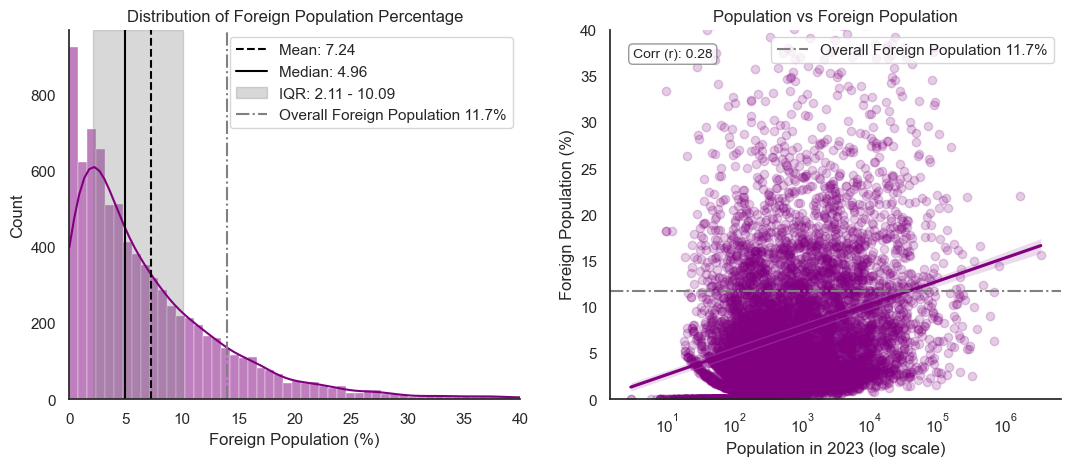

In [227]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_Foreign_population],
        title='Distribution of Foreign Population Percentage',
        xlabel='Foreign Population (%)',
        color='purple',
        limits=(0, 40),
        ax=axes[0]
)
axes[0].axvline(14.0, color='grey', linestyle='-.', label=f'Overall Foreign Population {11.7:.1f}%')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Foreign_population,
        title='Population vs Foreign Population',
        xlabel='Population in 2023 (log scale)',
        ylabel='Foreign Population (%)',
        color='purple',
        xscale='log',
        ylim=(0, 40),
        ax=axes[1]
)
axes[1].axhline(11.7, color='grey', linestyle='-.', label=f'Overall Foreign Population {11.7:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_distribution_foreign.png', bbox_inches='tight', dpi=300)

Again, as in the previous examples, the smaller municipalities, which tend to be rural and have small foreign populations, distort the distribution. Despite having a 12% of foreign population in Spain, half of the municipalities have a foreign population of less than 5%. The scatter plot shows that there are some municipalities, most of them with populations below 1000, that have no foreign population at all.

### Mean net income
The mean net income variable can provide insights into the economic status of the municipalities, which can also influence electoral behavior. Generally, income is positively correlated with the higher education level. 

--- Summary Statistics: Distribution of Mean Net Income ---


,count,mean,std,min,25%,50%,75%,max
rta_nt_med,"8,131.00","27,933.75","6,594.91",0.00,"23,277.00","27,074.00","30,992.00","83,377.00"


--- Summary Statistics: Distribution of Population over 16 with Higher Education ---


,count,mean,std,min,25%,50%,75%,max
pob_esup16,"8,131.00",22.83,10.97,0.00,16.28,22.07,29.34,63.41


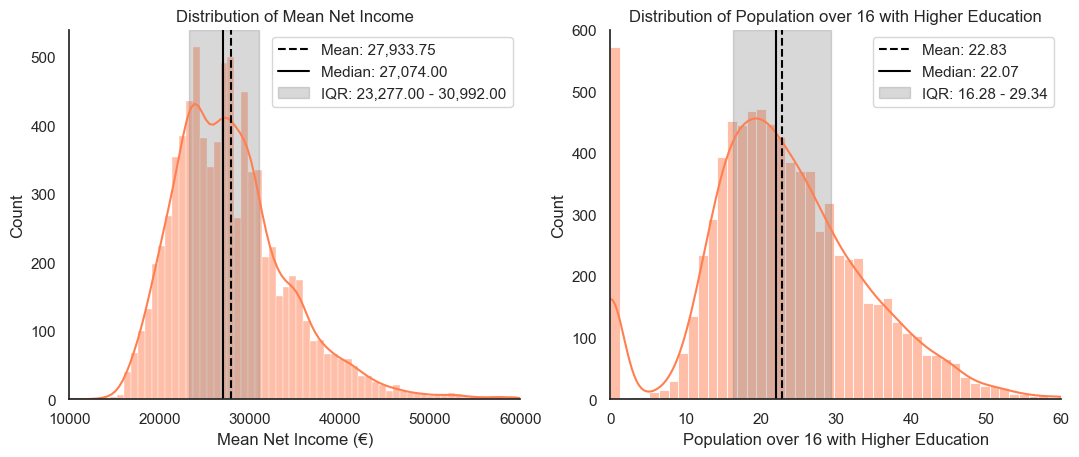

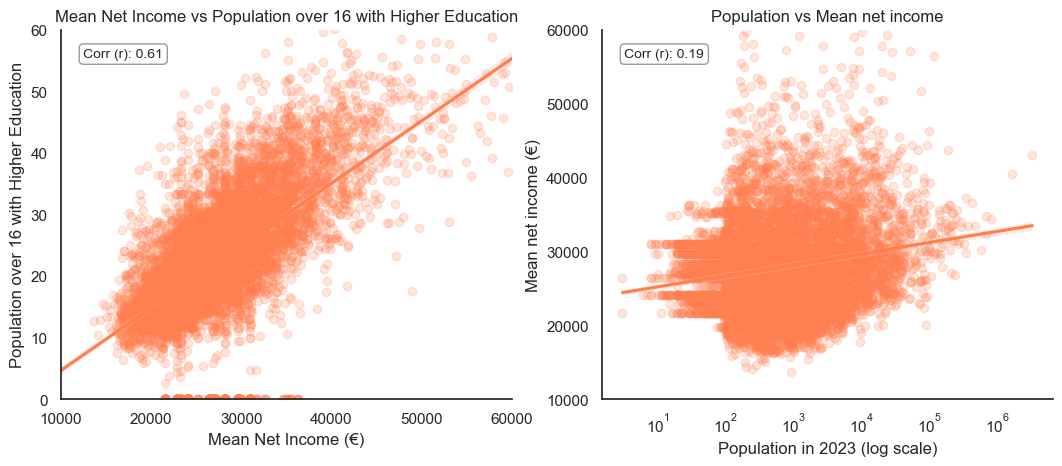

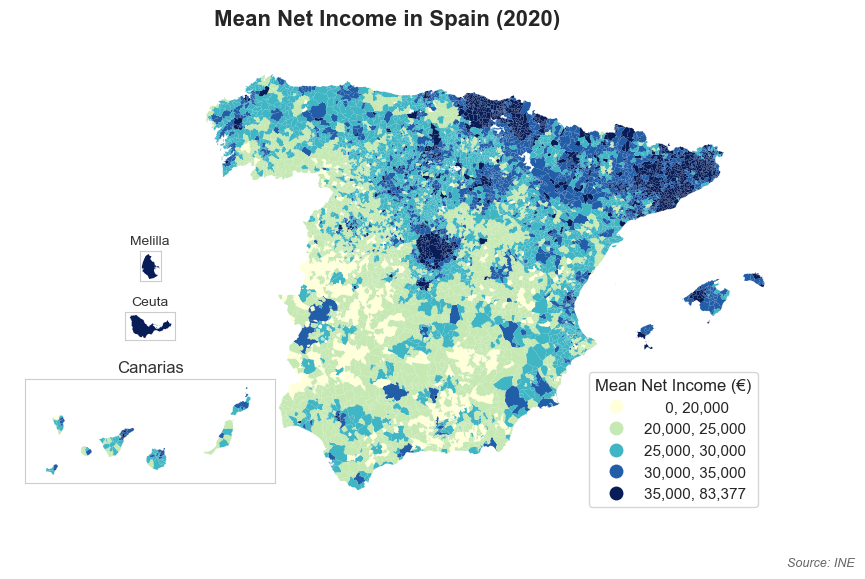

In [228]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_Mean_net_income],
        title='Distribution of Mean Net Income',
        xlabel='Mean Net Income (€)',
        color='coral',
        limits=(10000, 60000),
        ax=axes[0]
)
plot_distribution(
        gdf[V_Population_over_16_with_higher_education],
        title='Distribution of Population over 16 with Higher Education',
        xlabel='Population over 16 with Higher Education',
        color='coral',
        limits=(0, 60),
        ax=axes[1]
)
plot.savefig('02_images/02_distribution_income.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_Mean_net_income,
        y=V_Population_over_16_with_higher_education,
        title='Mean Net Income vs Population over 16 with Higher Education',
        xlabel='Mean Net Income (€)',
        ylabel='Population over 16 with Higher Education',
        color='coral',
        xlim=(10000, 60000),
        ylim=(0, 60),
        ax=axes[0]
)
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Mean_net_income,
        title='Population vs Mean net income',
        xlabel='Population in 2023 (log scale)',
        ylabel='Mean net income (€)',
        xscale='log',
        color='coral',
        ylim=(10000, 60000),
        ax=axes[1]
)
plot.savefig('02_images/02_scatter_income.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_Mean_net_income, 
    bins=[20000, 25000, 30000, 35000], 
    cmap='YlGnBu', 
    title='Mean Net Income in Spain (2020)', 
    legend_title='Mean Net Income (€)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_income.png', bbox_inches='tight', dpi=300)

As we can see in the second scatter plot, there is a positive correlation between mean net income and population size, which is expected as larger cities tend to have higher incomes due to scale economies. On the other hand, there is also a strong correlation between the mean net income and the population over 16 with higher education, which is also expected as higher education levels are often associated with higher income levels. About the distribution of the mean net income, it is also right-skewed, showing a long tail of municipalities with higher incomes, which reflects some inequality in the distribution of income.

It is interesting to note the presence of municipalities without population with higher education. Those are generally municipalities with very small and old populations in rural areas.

### Workforce affiliation and unemployment
The workforce affiliation and unemployment variables can provide insights into the economic activity and labor market conditions in the municipalities, which can also influence electoral behavior. Generally, higher workforce affiliation and lower unemployment rates are associated with better economic conditions and may influence voting patterns.

--- Summary Statistics: Distribution of Workforce Affiliation per 1000 Inhabitants ---


,count,mean,std,min,25%,50%,75%,max
afi_1000,"8,131.00",443.71,343.99,0.00,279.29,381.35,507.09,"7,293.24"


--- Summary Statistics: Distribution of Unemployment per 1000 Inhabitants ---


,count,mean,std,min,25%,50%,75%,max
paro_1000,"8,131.00",69.12,42.94,0.00,40.28,64.73,92.08,"1,000.00"


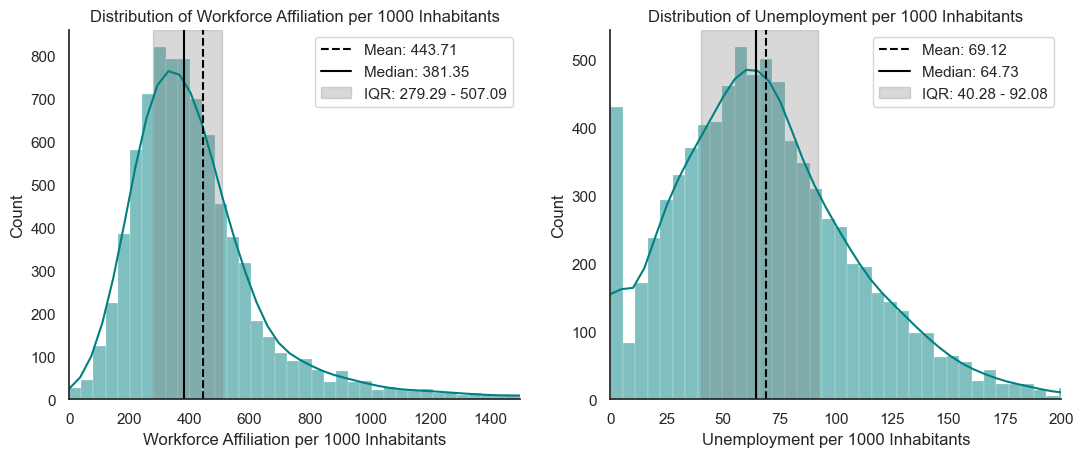

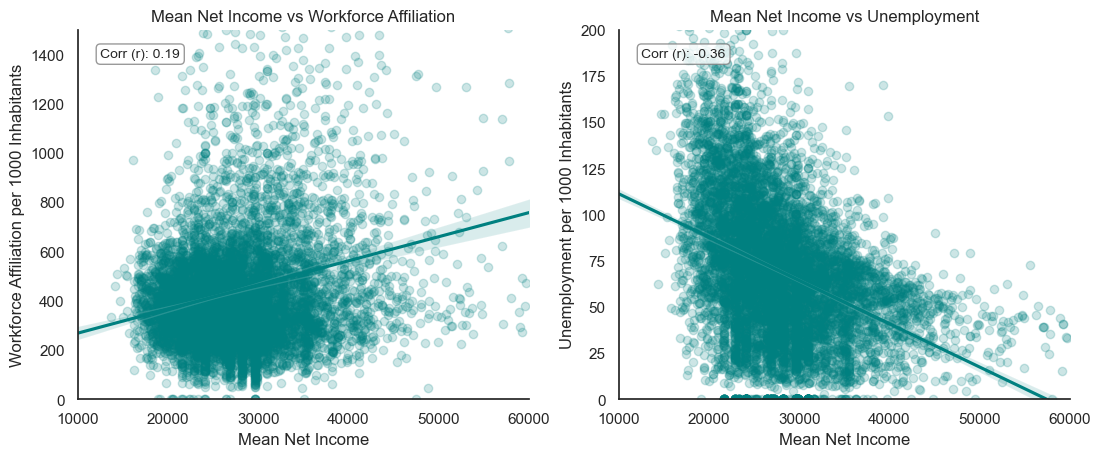

In [229]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_Affiliation_per_1000_inhabitants],
        title='Distribution of Workforce Affiliation per 1000 Inhabitants',
        xlabel='Workforce Affiliation per 1000 Inhabitants',
        color='teal',
        limits=(0, 1500),
        ax=axes[0]
)
plot_distribution(
        gdf[V_Unemployment_per_1000_inhabitants],
        title='Distribution of Unemployment per 1000 Inhabitants',
        xlabel='Unemployment per 1000 Inhabitants',
        color='teal',
        limits=(0, 200),
        ax=axes[1]
)
plot.savefig('02_images/02_distribution_workforce.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_Mean_net_income,
        y=V_Affiliation_per_1000_inhabitants,
        title='Mean Net Income vs Workforce Affiliation',
        xlabel='Mean Net Income',
        ylabel='Workforce Affiliation per 1000 Inhabitants',
        color='teal',
        xlim=(10000, 60000),
        ylim=(0, 1500),
        ax=axes[0]
)
plot_scatter(
        data=gdf,
        x=V_Mean_net_income,
        y=V_Unemployment_per_1000_inhabitants,
        title='Mean Net Income vs Unemployment',
        xlabel='Mean Net Income',
        ylabel='Unemployment per 1000 Inhabitants',
        color='teal',
        xlim=(10000, 60000),
        ylim=(0, 200),
        ax=axes[1]
)
plot.savefig('02_images/02_scatter_workforce.png', bbox_inches='tight', dpi=300)

As we could expect, there is a positive correlation between workforce affiliation and mean net income, as well as a negative correlation between unemployment and mean net income. The distributions are again right-skewed. It is remarkable the existance of some outliers with unemployment rates of 0%. This may seem an indication of a very good economic condition, but it is a consequence of the small and old populations with little economic activity and a high percentage of retired people. It is also interesting to note the presence of some municipalities with workforce affiliation rates above 100%, which is due to the fact that a worker is counted in the municipality where he works, which may be different from the municipality where he lives. Therefore, municipalities with small populations and strong economic activity may have workforce affiliation rates above 1000. The muncipality in Spain with the highest workforce affiliation rate is Figueruelas, with a workforce affiliation rate of almos 7300 due to the presence of a large automotive factory of Stellantis and a small population of around 1250 people. Another example is the municipality of Zamundio, being the location of a science park with 300 companies and more than 11000 workers, while having a population of around 3300 people, which leads to a workforce affiliation rate of around 7200..